In [1]:
import os
import torch
import matplotlib.pyplot as plt

# Import your project modules
import a1_cnn_ynlt.config as cfg
import cnn_utils.data as data_utils
from cnn_utils.model import load_model
from cnn_utils.evaluate import EvalClassification
from cnn_utils.predict import PredictPlants

# Ensure the figures directory exists
os.makedirs(cfg.FIGURE_SAVE_DIR, exist_ok=True)

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
# 1. Patching Parameters (Larger Context Windows)
cfg.patching_method = 'multi-scale'
cfg.padding_logic = 'reflect'
cfg.ms_scale = [0.4, 0.6, 0.8] 
cfg.ms_overlap = [0.2, 0.3, 0.4] 

# 2. Confusion Subsystem Parameters (Higher Sensitivity)
cfg.do_critical_review = True
cfg.critical_confusion_level = 1
cfg.margin_threshold = 0.5      
cfg.confidence_threshold = 0.8  
cfg.entropy_threshold = 1.0     
cfg.ignore_invasive_predictions = True 

# 3. Manuscript Formatting
cfg.SHOW_TITLES_IN_PLOTS = False # Set to False for LaTeX inclusion
cfg.apply_matplotlib_styles()    # Apply the Elsevier 'Times' styling

Global Matplotlib styles applied.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Champion Model
CHAMPION_MODEL_PATH = cfg.ph7_gated_attn_best_ood_acc
print(f"Loading Champion Model: {CHAMPION_MODEL_PATH}")
model_gated = load_model(CHAMPION_MODEL_PATH)
model_gated.to(device)
model_gated.eval()

# Load Data and Force Batch Size to 1 (Required for YNLT processing)
print("Loading Dataloaders...")
_, _, test_dl_lab = data_utils.get_3_dataloaders(cfg)
test_dl_lab_single = data_utils.make_batch_size_one(test_dl_lab)

_, test_dl_ood = data_utils.get_ood_dataloaders(cfg)
test_dl_ood_single = data_utils.make_batch_size_one(test_dl_ood)

Loading Champion Model: /home/takayuki/Desktop/summer2025/plants/training/phase7/models/best_ood_acc_model_07-31_04-19--55_ph7_gated_attn_actual_convnextv2_tiny.fcmae_ft_in22k_in1k.pth
Model loaded successfully from /home/takayuki/Desktop/summer2025/plants/training/phase7/models/best_ood_acc_model_07-31_04-19--55_ph7_gated_attn_actual_convnextv2_tiny.fcmae_ft_in22k_in1k.pth
Loading Dataloaders...
 Total dataset size 	: 230
 Train dataset size 	: 138
 Val dataset size 	: 46
 Test dataset size 	: 46

Found 10 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Potamogeton robbinsii', 'Ranunculus aquatilis']

OOD split complete:
  OOD Validation set size: 16
  OOD Test set size    : 17



In [4]:
# Initialize Predictor
predictor = PredictPlants(model_gated, "Gated Attention + YNLT")

# Create wrapper function for the evaluator
def predict_fn_ynlt(images, label):
    return predictor.predict(input=images, true_label=label, return_fig=False, display=False)

# Initialize Evaluators (Passing 'cfg' properly!)
eval_ood = EvalClassification(cfg, model=model_gated, dataloader=test_dl_ood_single)
eval_lab = EvalClassification(cfg, model=model_gated, dataloader=test_dl_lab_single)

print("Running YNLT evaluations on OOD Data...")
eval_ood.evaluate(predict_function=predict_fn_ynlt)

print("Running YNLT evaluations on Lab Data...")
eval_lab.evaluate(predict_function=predict_fn_ynlt)

print("Evaluations complete! Ready to generate figures.")

Running YNLT evaluations on OOD Data...


  -- Evaluating: 100%|██████████| 17/17 [00:04<00:00,  3.50it/s]


Running YNLT evaluations on Lab Data...


  -- Evaluating: 100%|██████████| 46/46 [00:12<00:00,  3.80it/s]

Evaluations complete! Ready to generate figures.


Generating Binary Confusion Matrix for Lab Set...


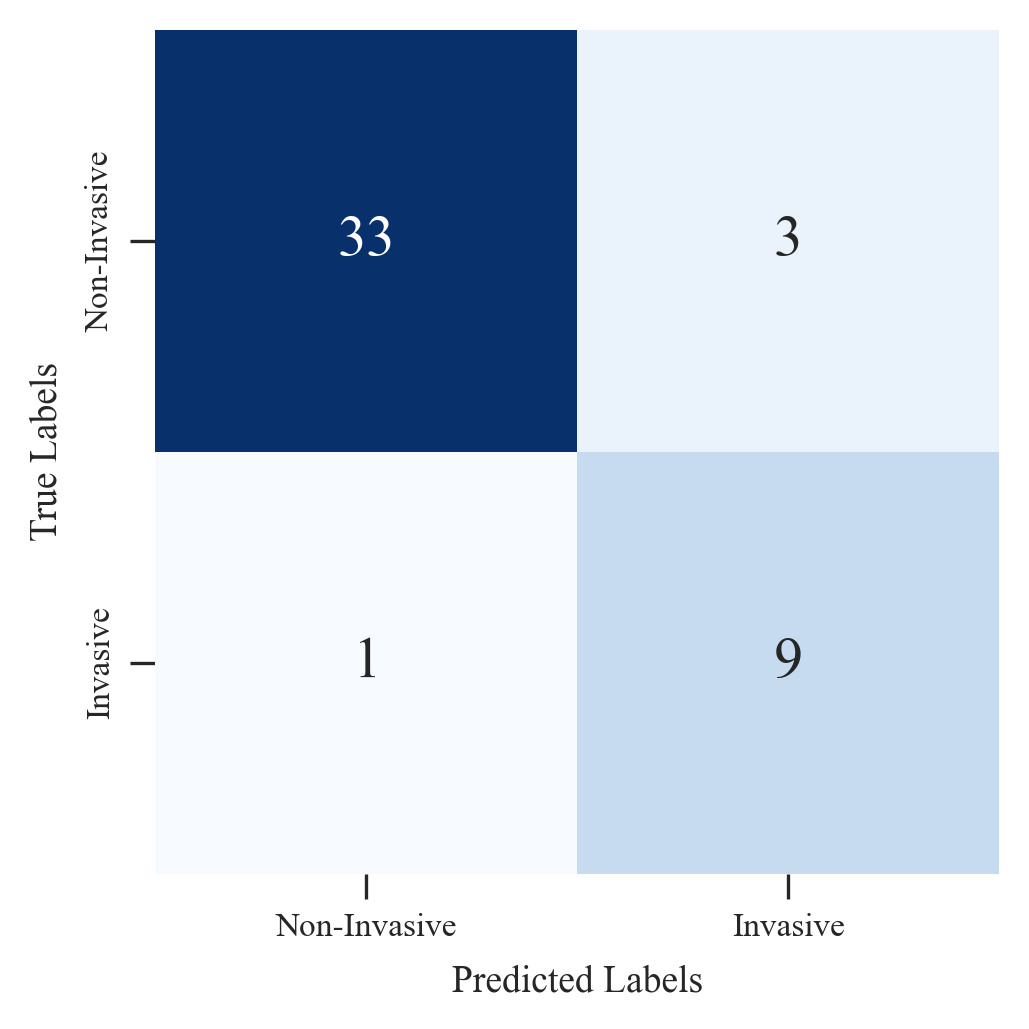

Saved to: /home/takayuki/Desktop/summer2025/plants/plant_classification/../figures26/lab_binary_cm.pdf


In [8]:
# print("Generating Binary Confusion Matrix for OOD Set...")

# # Get the figure object
# cm_binary, fig_binary = eval_ood.get_binary_confusion_matrix(display=True, return_fig=True)

# # Save it directly to your figures folder
# save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "ood_binary_cm.pdf")
# fig_binary.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
# print(f"Saved to: {save_path}")

print("Generating Binary Confusion Matrix for Lab Set...")

# Get the figure object
cm_binary, fig_binary = eval_lab.get_binary_confusion_matrix(display=True, return_fig=True)

# Save it directly to your figures folder
save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "lab_binary_cm.pdf")
fig_binary.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
print(f"Saved to: {save_path}")

Generating Class-wise Confusion Matrix for Lab Set...


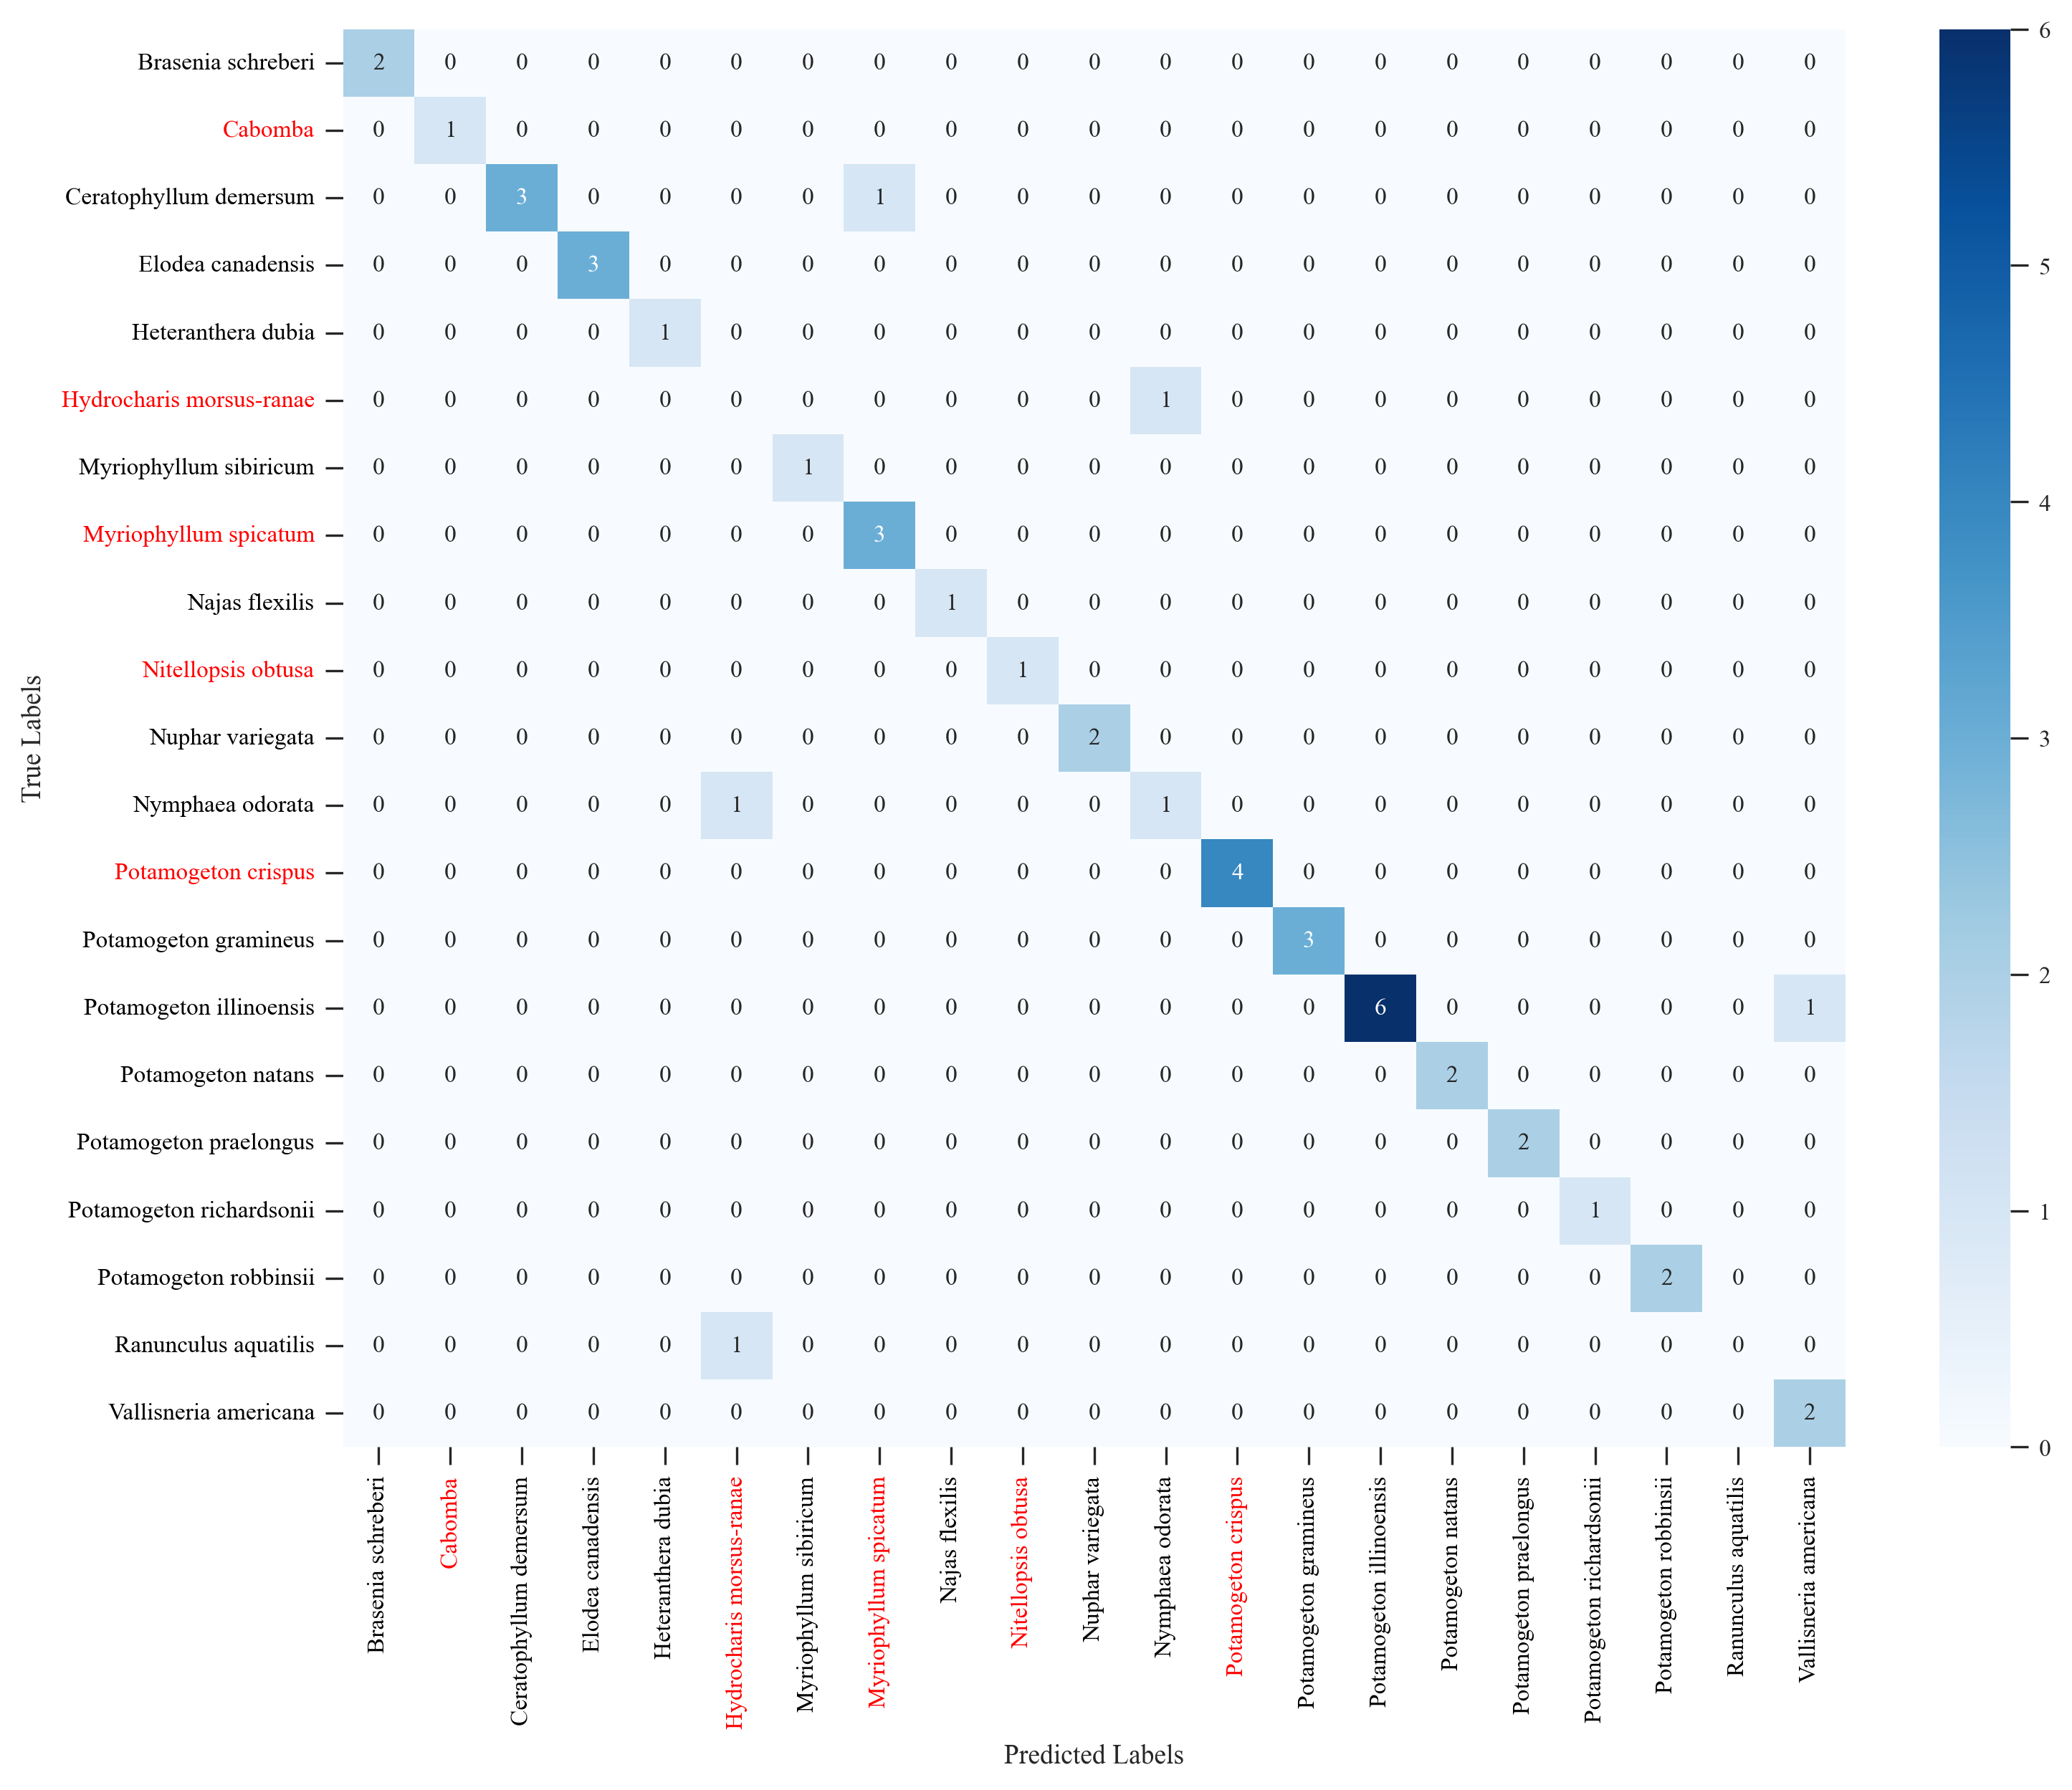

Saved to: /home/takayuki/Desktop/summer2025/plants/plant_classification/../figures26/lab_classwise_cm.pdf


In [11]:
# print("Generating Class-wise Confusion Matrix for OOD Set...")

# # You can pass a custom figsize if 21 classes overlap too much
# custom_figsize = (cfg.FIG_WIDTH_DOUBLE_COL_INCH * 1.5, cfg.FIG_WIDTH_DOUBLE_COL_INCH * 1.2)

# cm_class, fig_class = eval_ood.get_classwise_confusion_matrix(display=True, return_fig=True, figsize=custom_figsize)

# save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "ood_classwise_cm.pdf")
# fig_class.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
# print(f"Saved to: {save_path}")

print("Generating Class-wise Confusion Matrix for Lab Set...")

# You can pass a custom figsize if 21 classes overlap too much
custom_figsize = (cfg.FIG_WIDTH_DOUBLE_COL_INCH * 1.5, cfg.FIG_WIDTH_DOUBLE_COL_INCH * 1.2)

cm_class, fig_class = eval_lab.get_classwise_confusion_matrix(display=True, return_fig=True, figsize=custom_figsize)

save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "lab_classwise_cm.pdf")
fig_class.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
print(f"Saved to: {save_path}")



Generating Butterfly Bar Chart for Lab Set...


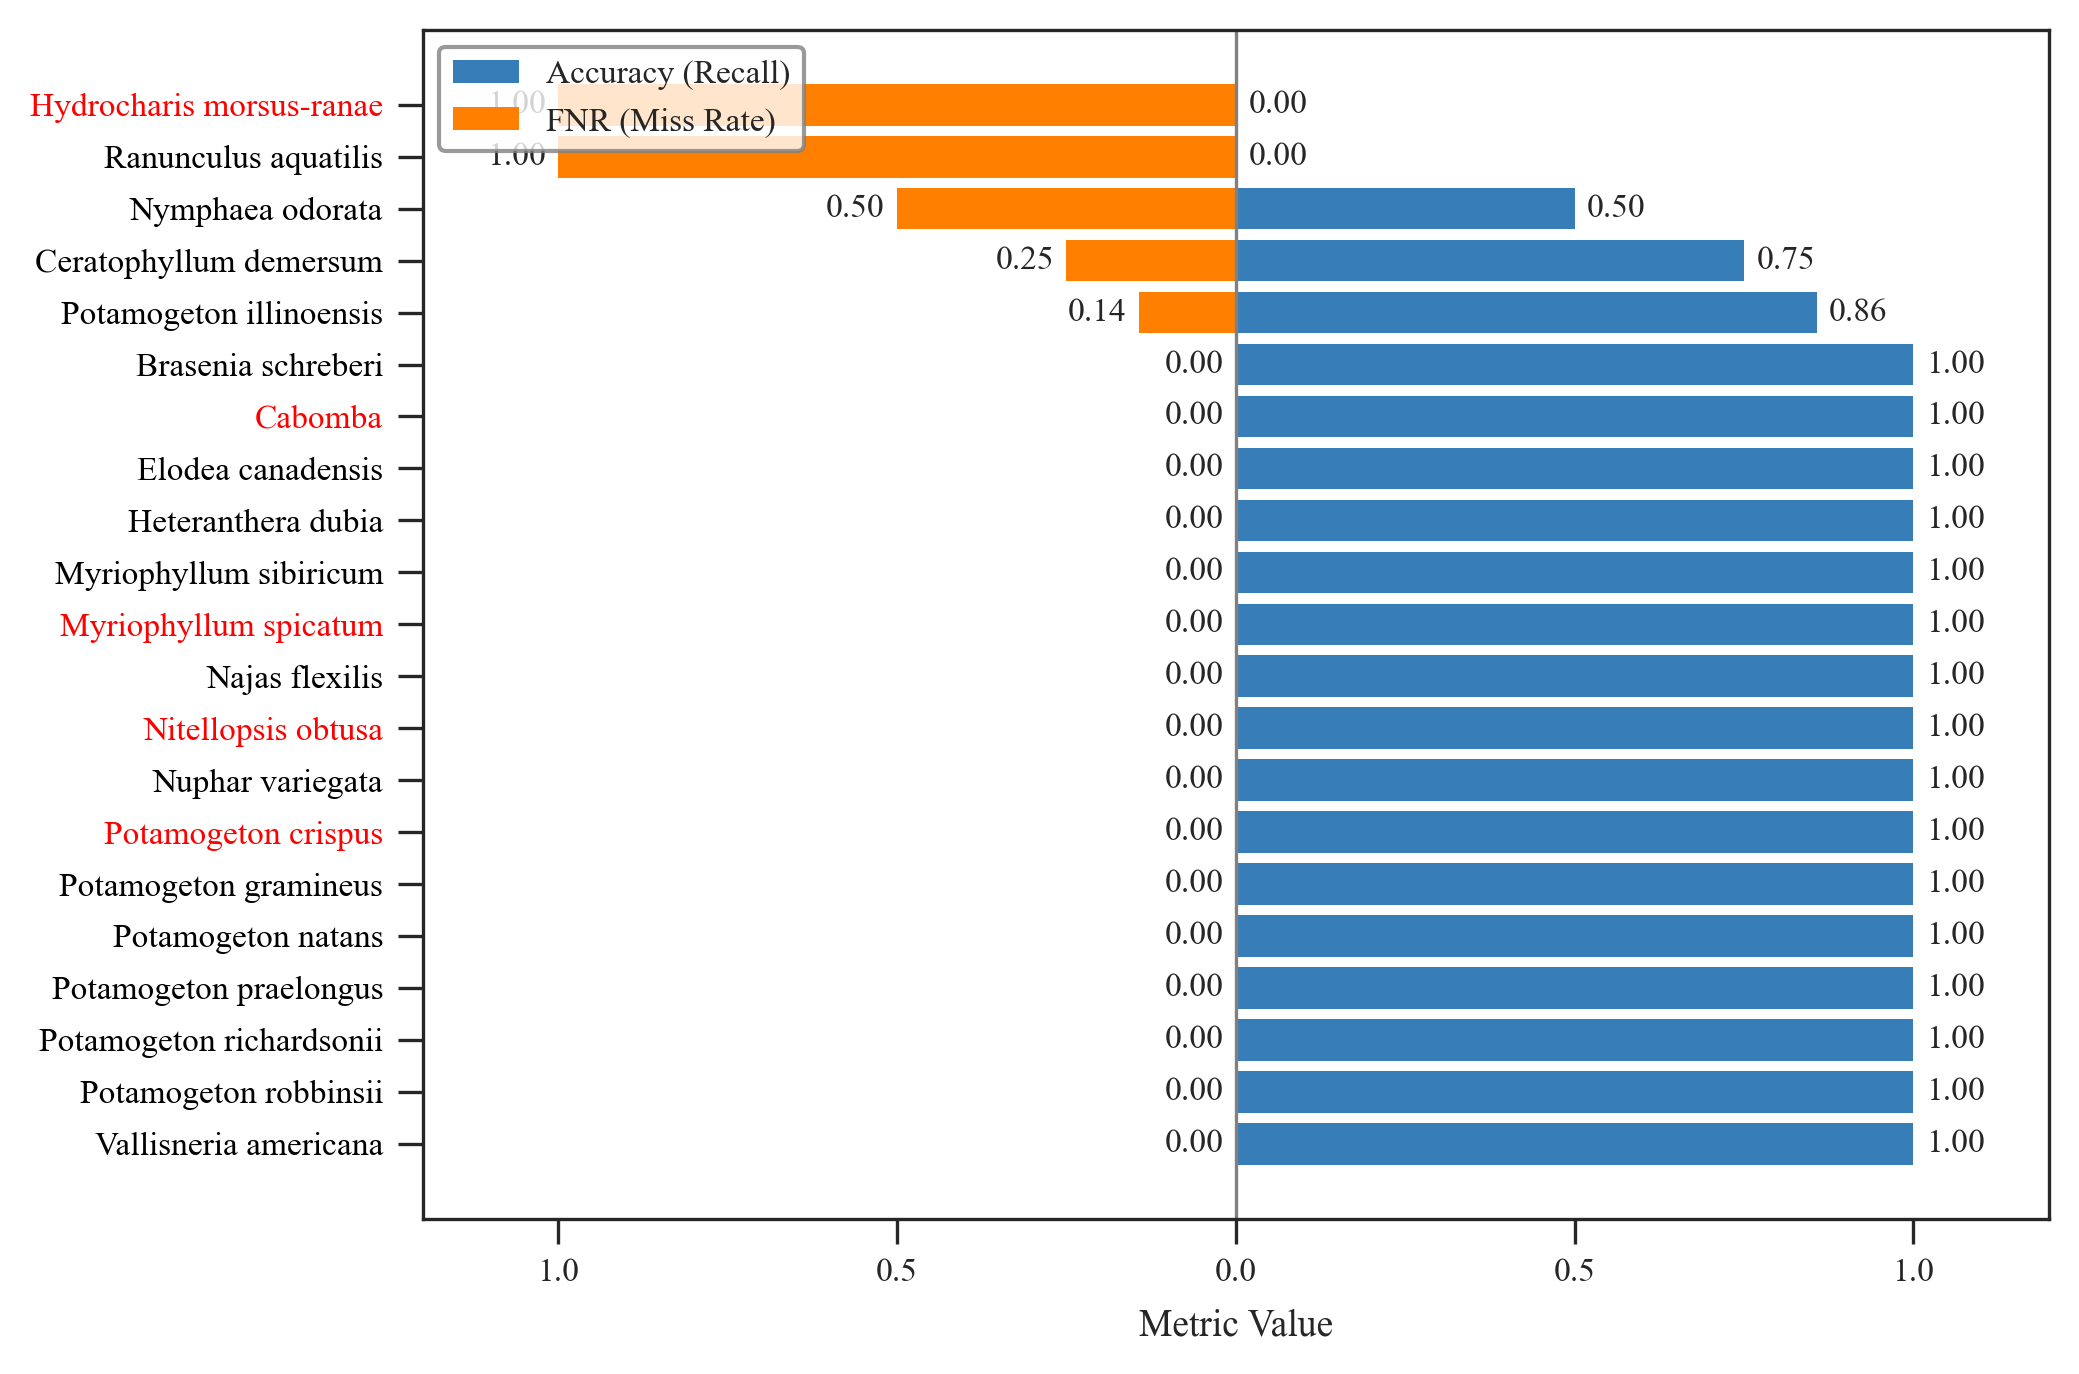

Saved to: /home/takayuki/Desktop/summer2025/plants/plant_classification/../figures26/lab_butterfly_chart.pdf


In [10]:
# print("Generating Butterfly Bar Chart for OOD Set...")

# # Sort by 'fnr' or 'accuracy' to make the chart tell a specific story
# fig_butterfly = eval_ood.visualize_classwise_metrics(sort_by='fnr', display=True, return_fig=True)

# save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "ood_butterfly_chart.pdf")
# fig_butterfly.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
# print(f"Saved to: {save_path}")

print("Generating Butterfly Bar Chart for Lab Set...")

# Sort by 'fnr' or 'accuracy' to make the chart tell a specific story
fig_butterfly = eval_lab.visualize_classwise_metrics(sort_by='fnr', display=True, return_fig=True)

save_path = os.path.join(cfg.FIGURE_SAVE_DIR, "lab_butterfly_chart.pdf")
fig_butterfly.savefig(save_path, dpi=cfg.FIGURE_DPI, bbox_inches='tight')
print(f"Saved to: {save_path}")